In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/Colab_Notebooks/cancer_dataset.zip

/content/drive/MyDrive/Colab_Notebooks/cancer_dataset.zip


In [3]:
!unzip cancer_dataset.zip -d /content/
!ls /content/drive/MyDrive/Colab_Notebooks/cancer_dataset.zip/images/train
!ls /content/drive/MyDrive/Colab_Notebooks/cancer_dataset.zip/labels/train

unzip:  cannot find or open cancer_dataset.zip, cancer_dataset.zip.zip or cancer_dataset.zip.ZIP.
17.jpg	18.jpg	19.jpg	20.jpg
17.txt	18.txt	19.txt	20.txt


In [4]:
import os

# Count how many image and label files are there
train_images = '/content/drive/MyDrive/Colab_Notebooks/cancer_dataset.zip/images/train'
train_labels = '/content/drive/MyDrive/Colab_Notebooks/cancer_dataset.zip/labels/train'

print("Train images:", len(os.listdir(train_images)))
print("Train labels:", len(os.listdir(train_labels)))

Train images: 4
Train labels: 4


In [6]:
# Move to YOLOv5 and install dependencies
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt

# Create the YAML config
data_yaml = """
train: /content/drive/MyDrive/Colab_Notebooks/cancer_dataset.zip/images/train
val: /content/drive/MyDrive/Colab_Notebooks/cancer_dataset.zip/images/train
nc: 1
names: ['cancer_cell']
"""
with open("cancer.yaml", "w") as f:
    f.write(data_yaml)

# Train model
!python train.py --img 640 --batch 2 --epochs 20 --data cancer.yaml --weights yolov5s.pt --cache

fatal: destination path 'yolov5' already exists and is not an empty directory.
/content/drive/My Drive/Colab_Notebooks/cancer_dataset.zip/yolov5/yolov5
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-07 05:23:44.862659: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775539424.927552   15574 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775539424.946809   15574 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775539425.000236   15574 computation_placer.cc:177] computation placer already registered. Please check linkage

In [7]:
!python train.py --img 640 --batch 2 --epochs 20 --data cancer.yaml --weights yolov5s.pt --cache

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-07 05:29:29.066727: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775539769.091810   17180 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775539769.099559   17180 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775539769.119184   17180 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775539769.119228   17180 computation_placer.cc:177] computation placer already registere

In [8]:
pred_txt_path = "/content/drive/MyDrive/Colab_Notebooks/cancer_dataset.zip/labels/train/19.txt"

with open(pred_txt_path, 'r') as f:
    predictions = f.readlines()

for line in predictions:
    print(line.strip())

0 0.4 0.5 0.1 0.1


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved YOLO output image to: /content/drive/MyDrive/cancer_dataset.zip/cancer_output/19output.jpg


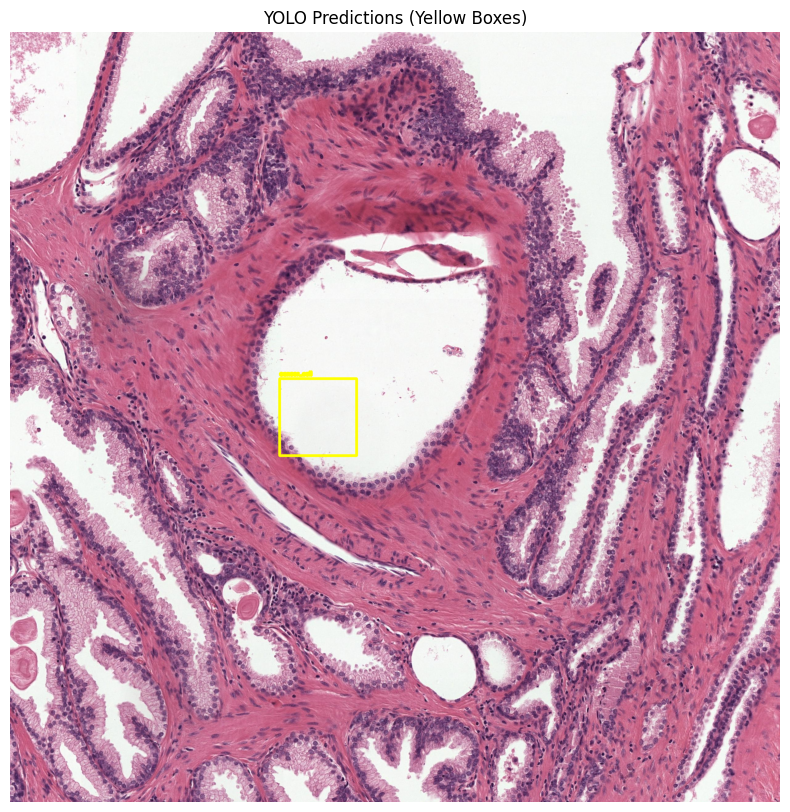

In [9]:
import cv2
import matplotlib.pyplot as plt
import os
from google.colab import drive
import shutil

# STEP 0: Mount Google Drive
drive.mount('/content/drive')

# STEP 1: Set paths
image_path = "/content/drive/MyDrive/Colab_Notebooks/cancer_dataset.zip/images/train/19.jpg"
yolo_pred_path = "/content/drive/MyDrive/Colab_Notebooks/cancer_dataset.zip/labels/train/19.txt"
save_dir = "/content/drive/MyDrive/cancer_dataset.zip/cancer_output"
os.makedirs(save_dir, exist_ok=True)

# STEP 2: Load image
img = cv2.imread(image_path)
h, w, _ = img.shape

# STEP 3: Load YOLO predictions
def load_yolo_predictions(label_file):
    boxes = []
    with open(label_file, 'r') as f:
        for line in f:
            values = list(map(float, line.strip().split()))
            if len(values) == 6:
                class_id, x_center, y_center, box_w, box_h, conf = values
            else:
                class_id, x_center, y_center, box_w, box_h = values
                conf = None
            x1 = int((x_center - box_w / 2) * w)
            y1 = int((y_center - box_h / 2) * h)
            x2 = int((x_center + box_w / 2) * w)
            y2 = int((y_center + box_h / 2) * h)
            boxes.append((x1, y1, x2, y2, class_id, conf))
    return boxes

boxes = load_yolo_predictions(yolo_pred_path)

# STEP 4: Draw the predicted boxes
for box in boxes:
    x1, y1, x2, y2, class_id, conf = box
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 255), 8)
    label = f"cancer_cell {conf:.2f}" if conf else "cancer_cell"
    cv2.putText(img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 8)

# STEP 5: Save output image to Google Drive
output_path = os.path.join(save_dir, "19output.jpg")
cv2.imwrite(output_path, img)
print(f"Saved YOLO output image to: {output_path}")

# STEP 6: Display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("YOLO Predictions (Yellow Boxes)")
plt.show()

In [1]:
import cv2

In [2]:
from PIL import Image

In [3]:
img= Image.open('/content/drive/MyDrive/Colab_Notebooks/cancer_dataset.zip/images/train/17.jpg')

In [4]:
width, height= img.size

In [5]:
print("width", width)
print("height", height)
print("Resolution", width, "x", height)

width 2500
height 2500
Resolution 2500 x 2500
